Python environment is ready!
Dataset shape: (9471, 17)

Columns:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Data types:
Date              object
Time              object
CO(GT)            object
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)          object
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                 object
RH                object
AH                object
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object
Shape after cleaning: (9471, 15)

Missing values:
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          114
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)  

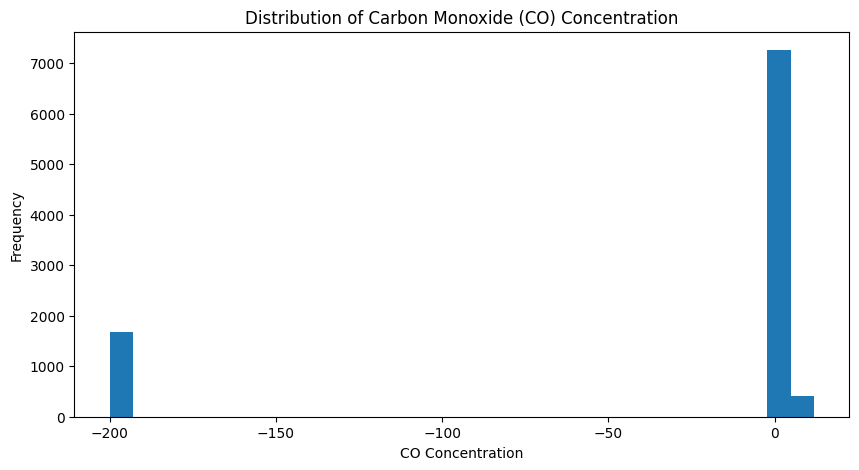

Remaining missing values:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)         0
C6H6(GT)          366
PT08.S2(NMHC)       0
NOx(GT)             0
PT08.S3(NOx)        0
NO2(GT)             0
PT08.S4(NO2)        0
PT08.S5(O3)         0
T                 366
RH                366
AH                366
dtype: int64


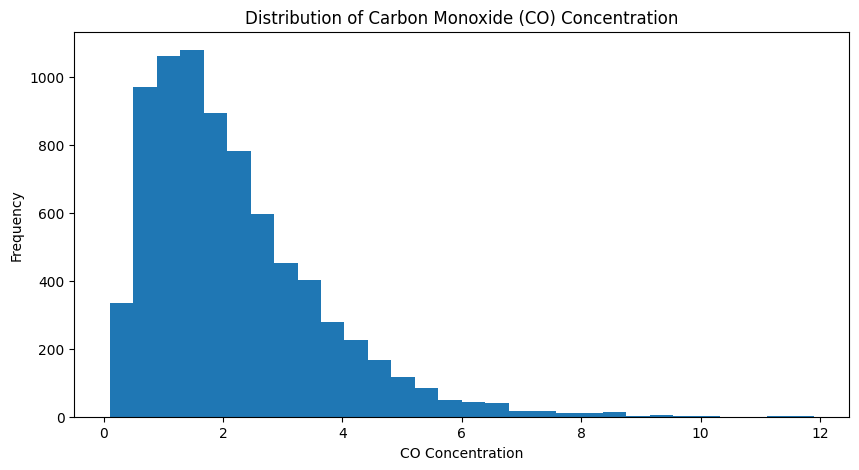

<Figure size 1200x500 with 0 Axes>

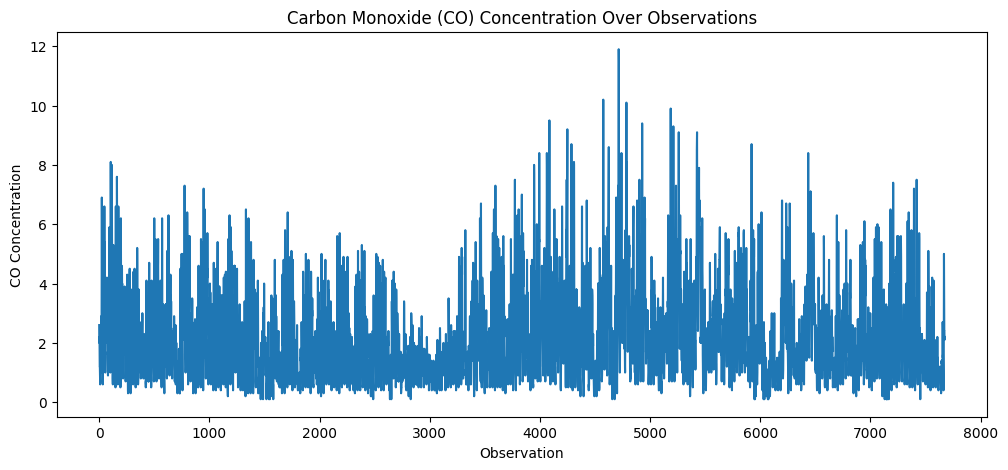

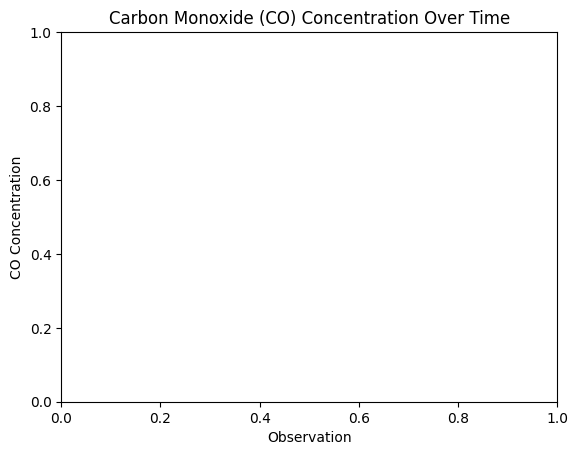

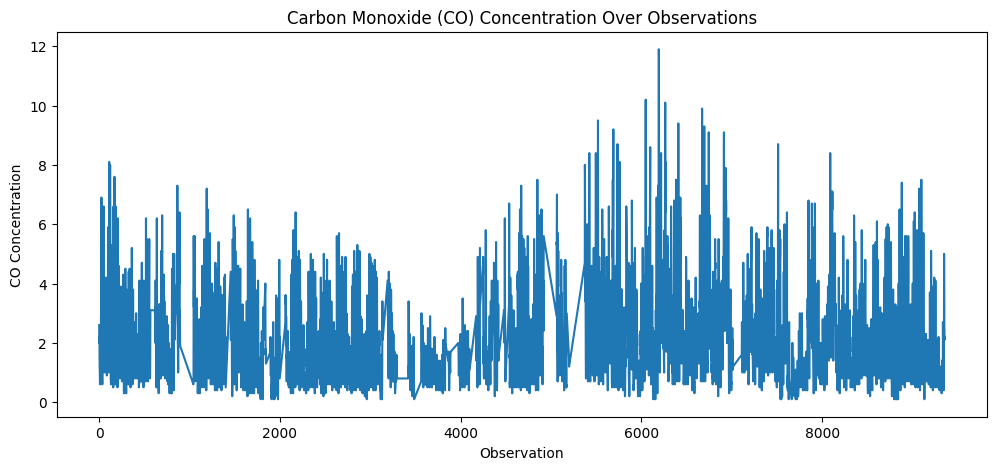

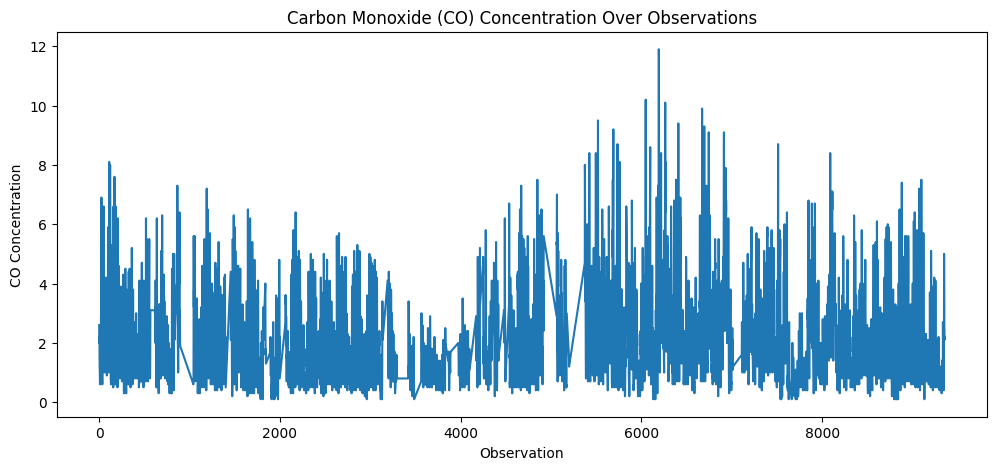

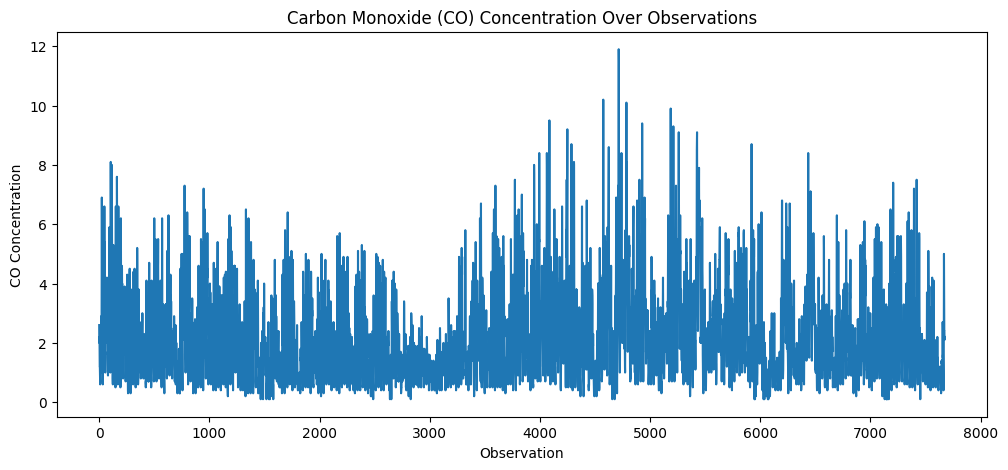

<Figure size 1000x600 with 0 Axes>

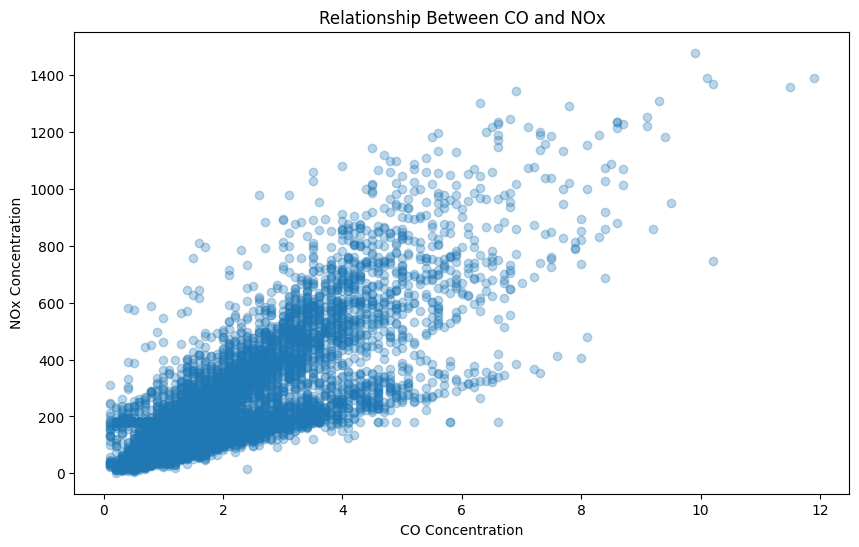

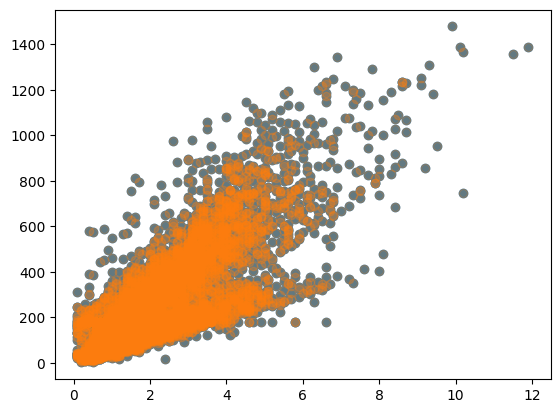

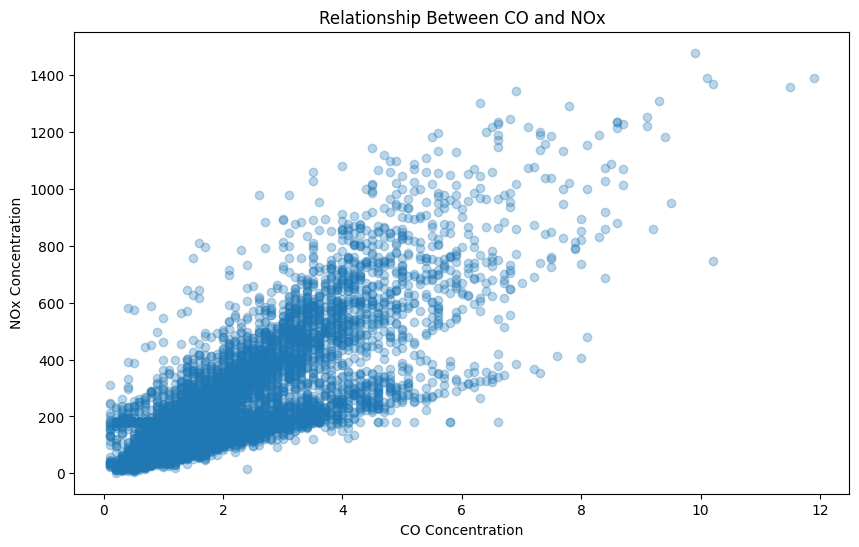

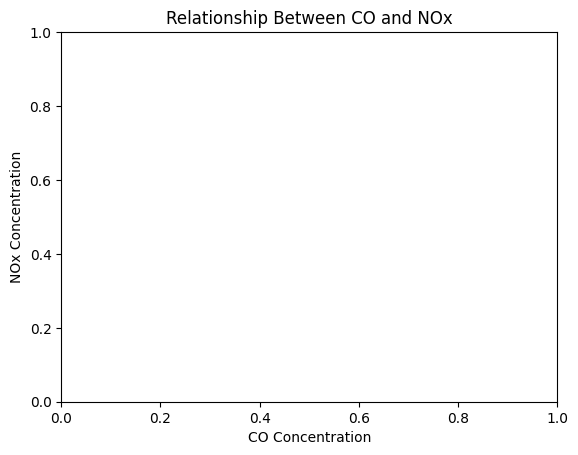

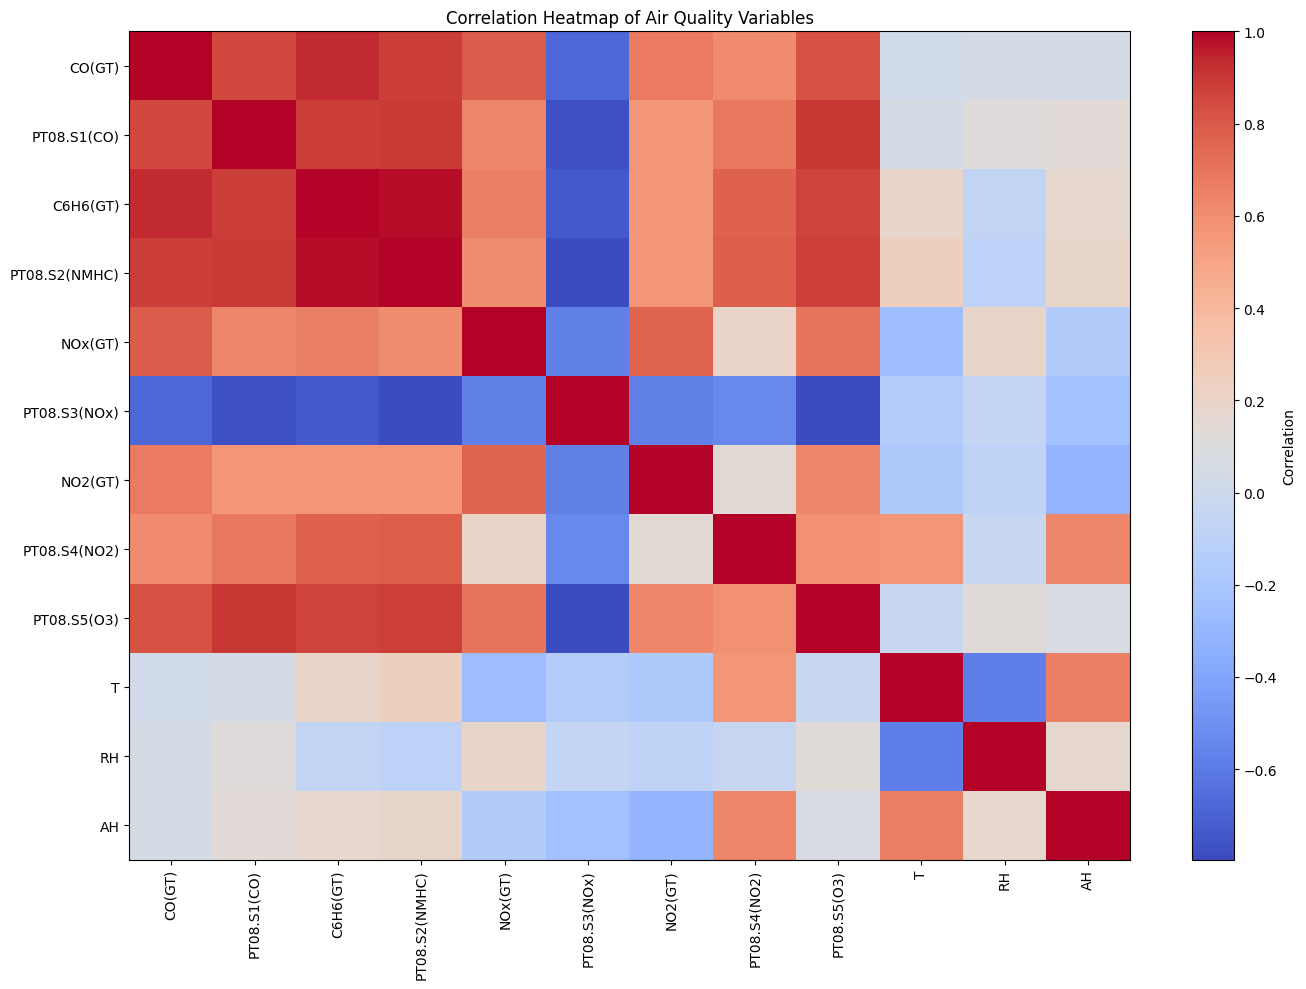

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

print("Python environment is ready!")
import pandas as pd

df = pd.read_csv("/content/AirQualityUCI.csv", sep=";")

df.head()
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)
# Remove unnecessary empty columns
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])

# Replace missing-value code with NaN
df = df.replace(-200, pd.NA)

# Convert comma decimals to numbers
for col in df.columns:
    if col not in ["Date", "Time"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Check the cleaned dataset
print("Shape after cleaning:", df.shape)

print("\nMissing values:")
print(df.isna().sum())
# Remove rows where Date or Time is missing
df = df.dropna(subset=["Date", "Time"])

# Drop NMHC(GT) because most values are missing
df = df.drop(columns=["NMHC(GT)"])

# Fill remaining missing numeric values with median
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Check result
print("Shape after missing-value treatment:", df.shape)

print("\nRemaining missing values:")
print(df.isna().sum())
# Basic statistical summary
df.describe()
# CO concentration distribution

plt.figure(figsize=(10, 5))

plt.hist(df["CO(GT)"], bins=30)

plt.xlabel("CO Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of Carbon Monoxide (CO) Concentration")

plt.show()
# Replace -200 with missing values
df = df.replace(-200, pd.NA)

# Convert numeric columns back to numeric
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Check remaining missing values
print("Remaining missing values:")
print(df.isna().sum())
# CO concentration distribution

plt.figure(figsize=(10, 5))

plt.hist(df["CO(GT)"].dropna(), bins=30)

plt.xlabel("CO Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of Carbon Monoxide (CO) Concentration")

plt.show()
# CO concentration over observations

plt.figure(figsize=(12, 5))


co_data = pd.to_numeric(df["CO(GT)"], errors="coerce")

co_data = co_data.dropna()

plt.figure(figsize=(12, 5))
plt.plot(co_data.to_numpy())

plt.xlabel("Observation")
plt.ylabel("CO Concentration")
plt.title("Carbon Monoxide (CO) Concentration Over Observations")

plt.show()

plt.xlabel("Observation")
plt.ylabel("CO Concentration")
plt.title("Carbon Monoxide (CO) Concentration Over Time")

plt.show()
# Remove missing CO values for plotting

co_data = df["CO(GT)"].dropna()

plt.figure(figsize=(12, 5))

plt.plot(co_data)

plt.xlabel("Observation")
plt.ylabel("CO Concentration")
plt.title("Carbon Monoxide (CO) Concentration Over Observations")

plt.show()
# Convert CO values to numbers
co_data = pd.to_numeric(df["CO(GT)"], errors="coerce").dropna()

# Plot CO concentration
plt.figure(figsize=(12, 5))

plt.plot(co_data)

plt.xlabel("Observation")
plt.ylabel("CO Concentration")
plt.title("Carbon Monoxide (CO) Concentration Over Observations")

plt.show()
co_data = pd.to_numeric(df["CO(GT)"], errors="coerce")

co_data = co_data.dropna()

plt.figure(figsize=(12, 5))
plt.plot(co_data.to_numpy())

plt.xlabel("Observation")
plt.ylabel("CO Concentration")
plt.title("Carbon Monoxide (CO) Concentration Over Observations")

plt.show()

plt.figure(figsize=(10, 6))
plot_data = df[["CO(GT)", "NOx(GT)"]].copy()

plot_data["CO(GT)"] = pd.to_numeric(plot_data["CO(GT)"], errors="coerce")
plot_data["NOx(GT)"] = pd.to_numeric(plot_data["NOx(GT)"], errors="coerce")

plot_data = plot_data.dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["CO(GT)"],
    plot_data["NOx(GT)"],
    alpha=0.3
)

plt.xlabel("CO Concentration")
plt.ylabel("NOx Concentration")
plt.title("Relationship Between CO and NOx")

plt.show()
plot_df = df[["CO(GT)", "NOx(GT)"]].dropna()

plt.scatter(
    plot_df["CO(GT)"],
    plot_df["NOx(GT)"],
)
plt.scatter(
    plot_df["CO(GT)"],
    plot_df["NOx(GT)"],
    alpha=0.3
)
# Convert CO and NOx columns to numeric
co_data = pd.to_numeric(df["CO(GT)"], errors="coerce")
nox_data = pd.to_numeric(df["NOx(GT)"], errors="coerce")

# Keep only rows where both values are available
plot_data = pd.DataFrame({
    "CO": co_data,
    "NOx": nox_data
}).dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["CO"],
    plot_data["NOx"],
    alpha=0.3
)

plt.xlabel("CO Concentration")
plt.ylabel("NOx Concentration")
plt.title("Relationship Between CO and NOx")

plt.show()
plt.xlabel("CO Concentration")
plt.ylabel("NOx Concentration")
plt.title("Relationship Between CO and NOx")

plt.show()

# Correlation Analysis of Air Quality Variables

# Make a copy of the dataset
corr_df = df.copy()

# Convert all relevant columns to numeric
for col in corr_df.columns:
    if col not in ["Date", "Time"]:
        corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

# Select numeric columns
numeric_df = corr_df.select_dtypes(include="number")

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Air Quality Variables")

plt.tight_layout()
plt.show()

In [10]:
print("DF exists:", 'df' in globals())
print("Rows:", len(df))
print(df.head())

DF exists: True
Rows: 9357
         Date      Time CO(GT)  PT08.S1(CO) C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
0  10/03/2004  18.00.00    2.6       1360.0     11.9         1046.0    166.0   
1  10/03/2004  19.00.00    2.0       1292.0      9.4          955.0    103.0   
2  10/03/2004  20.00.00    2.2       1402.0      9.0          939.0    131.0   
3  10/03/2004  21.00.00    2.2       1376.0      9.2          948.0    172.0   
4  10/03/2004  22.00.00    1.6       1272.0      6.5          836.0    131.0   

   PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  
0        1056.0    113.0        1692.0       1268.0  13.6  48.9  0.7578  
1        1174.0     92.0        1559.0        972.0  13.3  47.7  0.7255  
2        1140.0    114.0        1555.0       1074.0  11.9  54.0  0.7502  
3        1092.0    122.0        1584.0       1203.0  11.0  60.0  0.7867  
4        1205.0    116.0        1490.0       1110.0  11.2  59.6  0.7888  


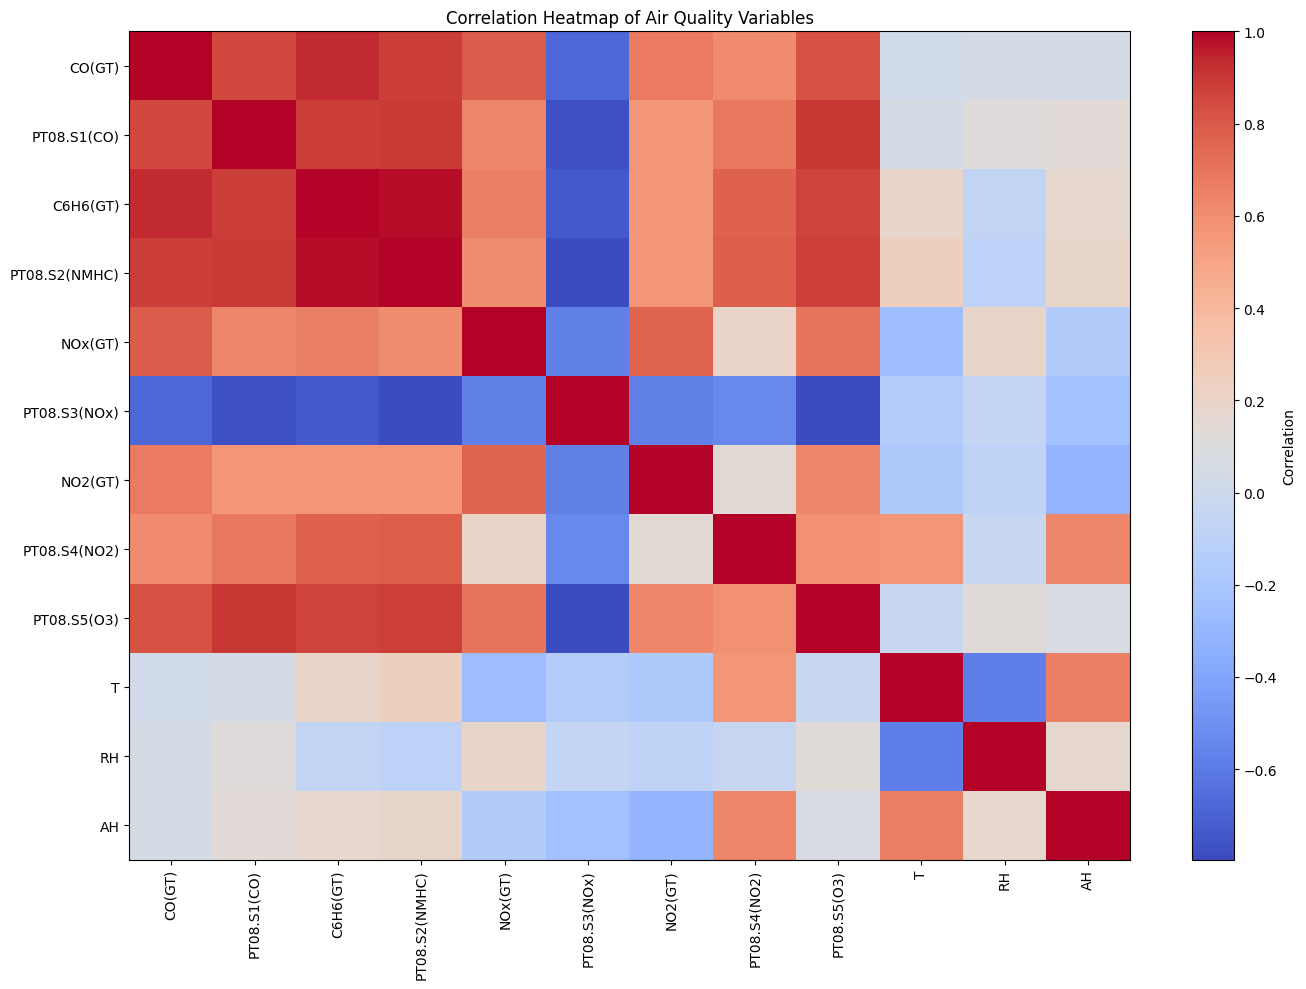

In [11]:
# Correlation Analysis of Air Quality Variables

# Make a copy of the dataset
corr_df = df.copy()

# Convert all relevant columns to numeric
for col in corr_df.columns:
    if col not in ["Date", "Time"]:
        corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

# Select numeric columns
numeric_df = corr_df.select_dtypes(include="number")

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Air Quality Variables")

plt.tight_layout()
plt.show()

In [12]:
print(type(correlation_matrix))
print(correlation_matrix)

<class 'pandas.core.frame.DataFrame'>
                 CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  \
CO(GT)         1.000000     0.846005  0.931078       0.882644  0.785672   
PT08.S1(CO)    0.846005     1.000000  0.883795       0.892989  0.622549   
C6H6(GT)       0.931078     0.883795  1.000000       0.981950  0.656335   
PT08.S2(NMHC)  0.882644     0.892989  0.981950       1.000000  0.606179   
NOx(GT)        0.785672     0.622549  0.656335       0.606179  1.000000   
PT08.S3(NOx)  -0.681374    -0.770544 -0.735744      -0.795792 -0.572440   
NO2(GT)        0.670869     0.563442  0.558710       0.561938  0.760716   
PT08.S4(NO2)   0.610640     0.682363  0.765731       0.776969  0.200825   
PT08.S5(O3)    0.822187     0.899417  0.865689       0.880633  0.694823   
T              0.022109     0.048627  0.198956       0.241373 -0.258027   
RH             0.048890     0.114606 -0.061681      -0.090380  0.193636   
AH             0.048556     0.135324  0.167972       0.186933 

CORRELATION MATRIX
                 CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  PT08.S3(NOx)   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)         T        RH        AH
CO(GT)         1.000000     0.846005  0.931078       0.882644  0.785672     -0.681374  0.670869      0.610640     0.822187  0.022109  0.048890  0.048556
PT08.S1(CO)    0.846005     1.000000  0.883795       0.892989  0.622549     -0.770544  0.563442      0.682363     0.899417  0.048627  0.114606  0.135324
C6H6(GT)       0.931078     0.883795  1.000000       0.981950  0.656335     -0.735744  0.558710      0.765731     0.865689  0.198956 -0.061681  0.167972
PT08.S2(NMHC)  0.882644     0.892989  0.981950       1.000000  0.606179     -0.795792  0.561938      0.776969     0.880633  0.241373 -0.090380  0.186933
NOx(GT)        0.785672     0.622549  0.656335       0.606179  1.000000     -0.572440  0.760716      0.200825     0.694823 -0.258027  0.193636 -0.154891
PT08.S3(NOx)  -0.681374    -0.770544 -0.735744      -0.795792 -

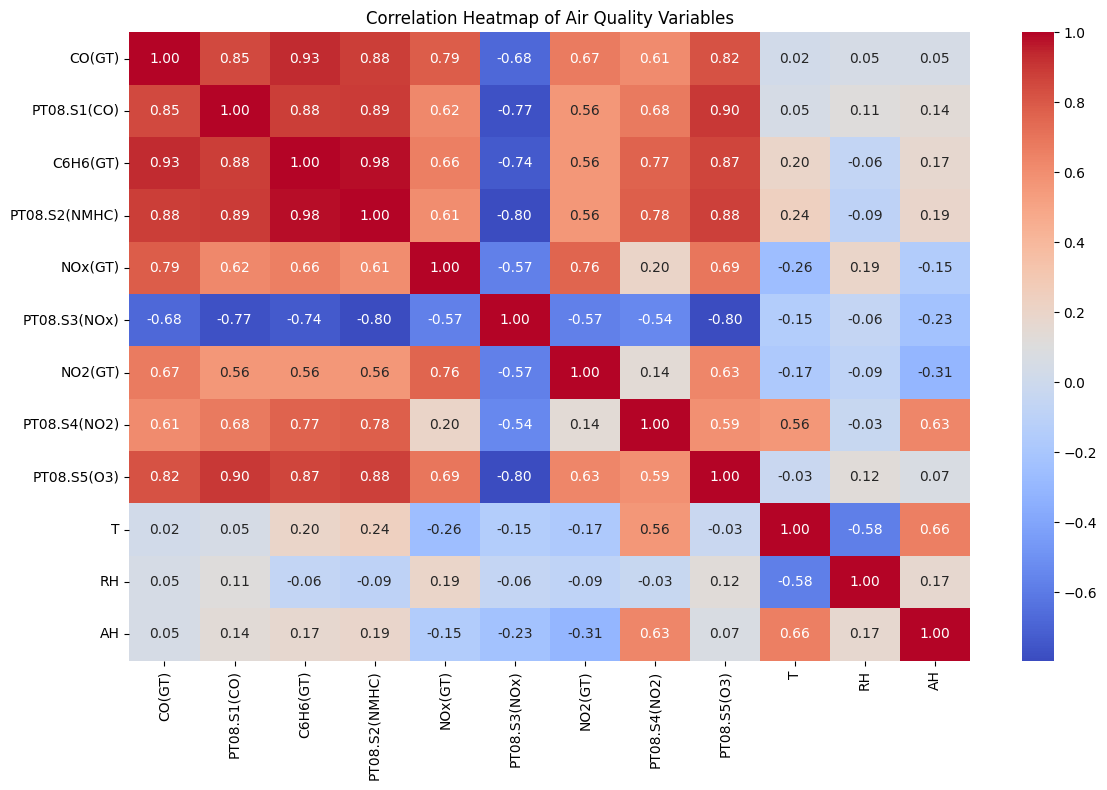

In [13]:
# Create correlation matrix directly from the dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert columns to numeric
corr_df = df.copy()

for col in corr_df.columns:
    if col not in ["Date", "Time"]:
        corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

# Select numeric columns
numeric_df = corr_df.select_dtypes(include="number")

# Calculate correlation
correlation_matrix = numeric_df.corr()

# Show result
print("CORRELATION MATRIX")
print(correlation_matrix.to_string())

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Air Quality Variables")
plt.tight_layout()
plt.show()

In [16]:
# 7. Train and compare machine-learning models

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Make a copy
model_df = df.copy()

# Convert all columns to numeric where possible
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Target
target = "CO(GT)"

# Check target
print("Target available:", target in model_df.columns)

# Remove rows where target is missing
model_df = model_df.dropna(subset=[target])

# Features: all numeric columns except target
X = model_df.drop(columns=[target])
y = model_df[target]

# Remove columns that contain no usable values
X = X.dropna(axis=1, how="all")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Models
models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# Train and evaluate
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

# Results table
results_df = pd.DataFrame(results)

print("\nModel Performance:")
display(results_df.round(4))

# Best model
best_index = results_df["R²"].idxmax()
best_model = results_df.loc[best_index]

print("\nBest Model:", best_model["Model"])
print("MAE:", round(best_model["MAE"], 4))
print("RMSE:", round(best_model["RMSE"], 4))
print("R²:", round(best_model["R²"], 4))

Target available: True

Model Performance:


,Model,MAE,RMSE,R²
0,Linear Regression,0.3072,0.4797,0.8895
1,Random Forest,0.2470,0.3948,0.9252



Best Model: Random Forest
MAE: 0.247
RMSE: 0.3948
R²: 0.9252


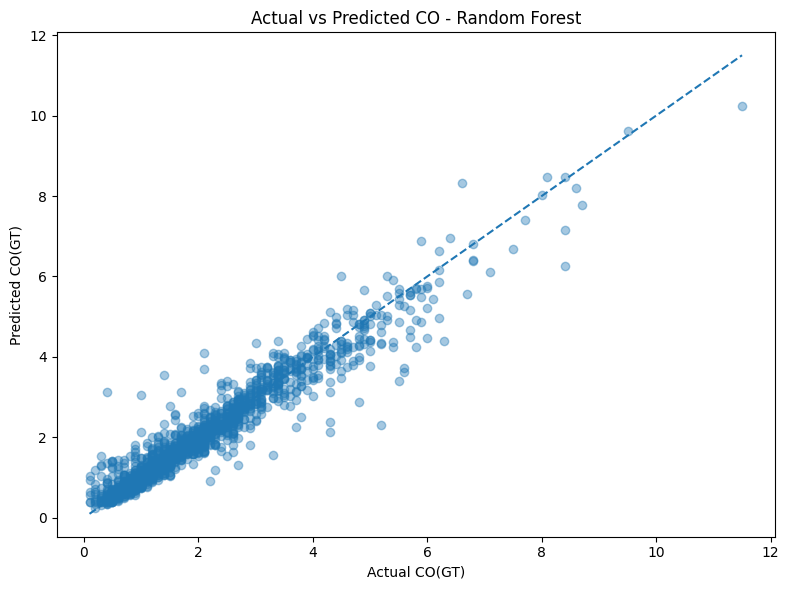

In [17]:
# 9. Actual vs Predicted CO

rf_model = models["Random Forest"]

predictions = rf_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.4)

min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Actual vs Predicted CO - Random Forest")
plt.tight_layout()
plt.show()

Top 10 features for CO prediction:


,Feature,Importance
2,PT08.S2(NMHC),0.6347
1,C6H6(GT),0.1774
3,NOx(GT),0.0861
0,PT08.S1(CO),0.0237
5,NO2(GT),0.0214
8,T,0.0148
7,PT08.S5(O3),0.0107
4,PT08.S3(NOx),0.0088
6,PT08.S4(NO2),0.0081
9,RH,0.0074


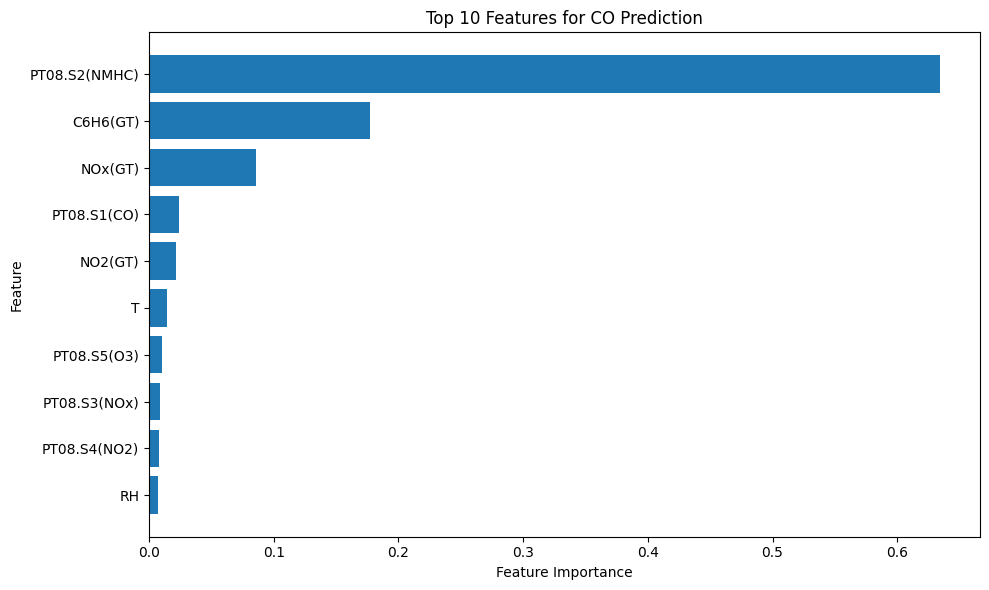

In [18]:
# 8. Feature Importance - Random Forest

# Get the trained Random Forest model
rf_model = models["Random Forest"]
rf = rf_model.named_steps["model"]

# Calculate feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 10 features for CO prediction:")
display(importance.head(10).round(4))

# Plot top 10 features
top_features = importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for CO Prediction")
plt.tight_layout()
plt.show()

## Conclusion

### Model Performance

Random Forest performed better than Linear Regression.

- Random Forest R²: **0.9252**
- Random Forest MAE: **0.2470**
- Random Forest RMSE: **0.3948**

### Key Findings

- **PT08.S2(NMHC)** was the most important feature for CO prediction.
- **C6H6(GT)** and **NOx(GT)** were also important predictors.
- The Actual vs Predicted plot shows that the Random Forest predictions generally follow the observed CO concentrations closely.

### Final Conclusion

Overall, the results demonstrate that machine-learning methods can effectively model CO concentration from air-quality sensor measurements. Random Forest provided the best predictive performance among the tested models.